In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, mannwhitneyu, ttest_ind
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from scipy.stats import norm

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('data/ab_data_tourist.csv')
df.head()

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   user_id   294478 non-null  int64
 1   date      294478 non-null  str  
 2   group     294478 non-null  str  
 3   purchase  294478 non-null  int64
 4   price     294478 non-null  int64
dtypes: int64(3), str(2)
memory usage: 11.2 MB


In [4]:
df.describe(include='all')

,user_id,date,group,purchase,price
count,294478.000000,294478,294478,294478.000000,294478.000000
unique,NaN,23,2,NaN,NaN
top,NaN,2021-01-08,B,NaN,NaN
freq,NaN,13564,147276,NaN,NaN
mean,787974.124733,NaN,NaN,0.119659,10154.782361
std,91210.823776,NaN,NaN,0.324563,35153.824872
min,630000.000000,NaN,NaN,0.000000,0.000000
25%,709032.250000,NaN,NaN,0.000000,0.000000
50%,787933.500000,NaN,NaN,0.000000,0.000000
75%,866911.750000,NaN,NaN,0.000000,0.000000


тест длился 23 дня

больше всего посещений было 8 января

13564 визита в этот день

2 группы — A и B

в группе B больше пользователей

In [5]:
df.groupby('group')['user_id'].count()

group
A    147202
B    147276
Name: user_id, dtype: int64

In [6]:
df[df['purchase'] == 1]['price'].value_counts()

price
10000     10510
100000     7170
60000      7091
150000     7008
200000     3458
Name: count, dtype: int64

In [7]:
df.groupby('group')['date'].agg(['min','max','nunique'])

,min,max,nunique
group,,,
A,2021-01-02,2021-01-24,23
B,2021-01-02,2021-01-24,23


В датасете отсутствуют пропущенные значения.

Набор данных содержит 294 478 наблюдений.

A/B-тест проводился в течение 23 дней.

Пользователи распределены между двумя группами: контрольной (A) и тестовой (B).

Средняя доля покупок составляет около 11.9%.

Максимальная стоимость тура составляет 200 000 рублей, минимальная — 10 000 рублей.

In [8]:
df['user_id'].nunique(), len(df)

(290584, 294478)

Видно, что уникальных пользователей меньше, чем строк, значит один пользователь мог заходить несколько раз -> конверсию считаем по визитам, а не по пользователям

In [9]:
cross_users = (
    df.groupby('user_id')['group']
    .nunique()
    .reset_index()
    .query('group > 1')
)

cross_users_count = cross_users.shape[0]
cross_users_count

1895

1895 пользователей, попавших в обе группы тестирования

In [10]:
bad_users = cross_users['user_id']
df = df[~df['user_id'].isin(bad_users)]

In [11]:
#Приводим типы
df['date'] = pd.to_datetime(df['date'])
df['group'] = df['group'].astype('category')
df['purchase'] = df['purchase'].astype('int')
df['price'] = df['price'].astype('float')

In [12]:
summary = df.groupby('group').agg(
    visits=('user_id', 'count'),
    purchases=('purchase', 'sum'),
    revenue=('price', 'sum')
)

summary

,visits,purchases,revenue
group,,,
A,145307,17487,1.417780e+09
B,145381,17290,1.533010e+09


In [13]:
#Посчитаем конверсию и средний чек
summary['conversion'] = summary['purchases'] / summary['visits']
summary['avg_check'] = summary['revenue'] / summary['purchases']
summary

,visits,purchases,revenue,conversion,avg_check
group,,,,,
A,145307,17487,1.417780e+09,0.120345,81076.228055
B,145381,17290,1.533010e+09,0.118929,88664.545980


In [14]:
tour_sales = pd.pivot_table(
    df[df['purchase'] == 1],
    values='user_id',
    index='price',
    columns='group',
    aggfunc='count',
    fill_value=0
)

tour_sales

group,A,B
price,,
10000.0,5182,5201
60000.0,5271,1730
100000.0,1832,5227
150000.0,3478,3438
200000.0,1724,1694


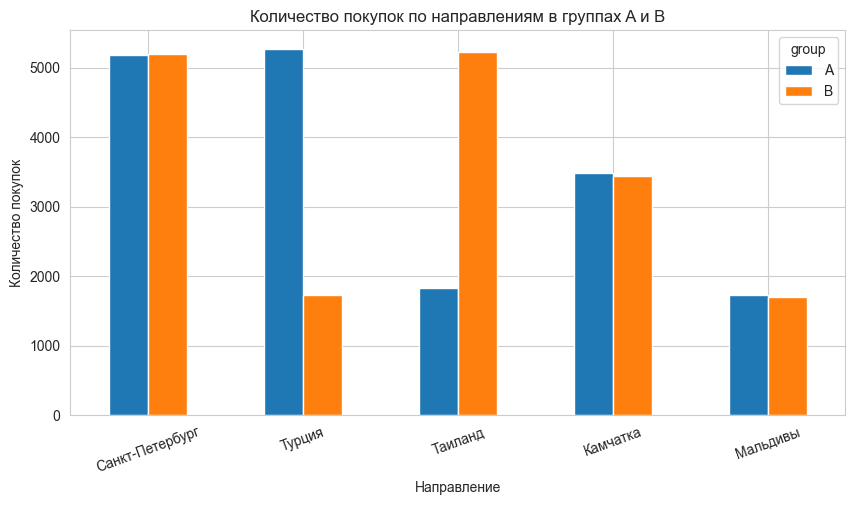

In [15]:
tour_map = {
    100000: 'Таиланд',
    60000: 'Турция',
    200000: 'Мальдивы',
    10000: 'Санкт-Петербург',
    150000: 'Камчатка'
}

tour_sales_named = tour_sales.copy()
tour_sales_named.index = tour_sales_named.index.map(tour_map)

tour_sales_named.plot(kind='bar')
plt.title('Количество покупок по направлениям в группах A и B')
plt.xlabel('Направление')
plt.ylabel('Количество покупок')
plt.xticks(rotation=20)
plt.show()

Распределение по турам сбалансировано у Санкт-Петербурга, Камчатки и Мальдив

Турция: преобладает у группы А

Тайланд: преобладает у группы В

In [16]:
daily = (
    df.groupby(['date', 'group'])
    .agg(
        visits=('user_id', 'count'),
        purchases=('purchase', 'sum'),
        revenue=('price', 'sum')
    )
    .reset_index()
)

daily['conversion'] = daily['purchases'] / daily['visits']
daily['avg_check'] = daily['revenue'] / daily['purchases']
daily.head()

,date,group,visits,purchases,revenue,conversion,avg_check
0,2021-01-02,A,2854,359,29410000.0,0.125788,81922.005571
1,2021-01-02,B,2861,345,29660000.0,0.120587,85971.014493
2,2021-01-03,A,6596,748,62000000.0,0.113402,82887.700535
3,2021-01-03,B,6619,754,65960000.0,0.113914,87480.106101
4,2021-01-04,A,6566,799,64250000.0,0.121687,80413.016270


In [17]:
daily = daily.sort_values(['group', 'date'])

daily['cum_visits'] = daily.groupby('group')['visits'].cumsum()
daily['cum_purchases'] = daily.groupby('group')['purchases'].cumsum()
daily['cum_revenue'] = daily.groupby('group')['revenue'].cumsum()

daily['cum_conversion'] = daily['cum_purchases'] / daily['cum_visits']
daily['cum_avg_check'] = daily['cum_revenue'] / daily['cum_purchases']

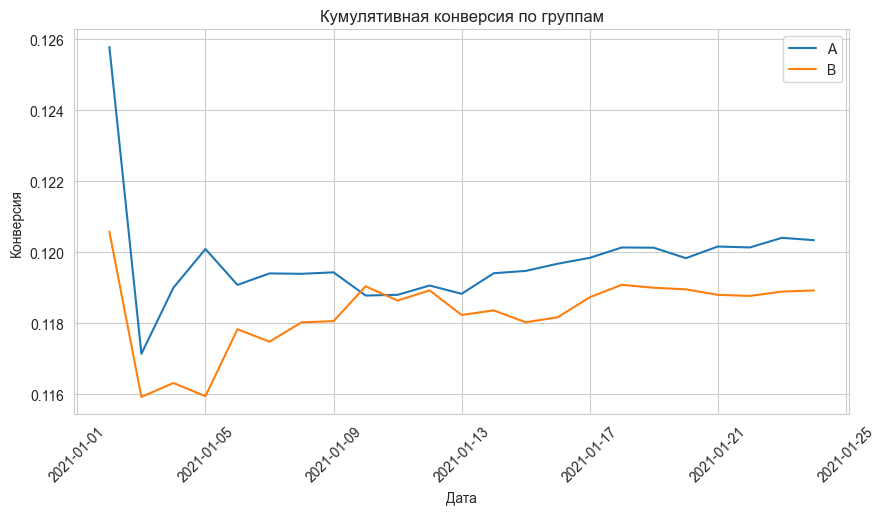

In [18]:
for group in daily['group'].unique():
    temp = daily[daily['group'] == group]
    plt.plot(temp['date'], temp['cum_conversion'], label=group)

plt.title('Кумулятивная конверсия по группам')
plt.xlabel('Дата')
plt.ylabel('Конверсия')
plt.legend()
plt.xticks(rotation=45)
plt.show()

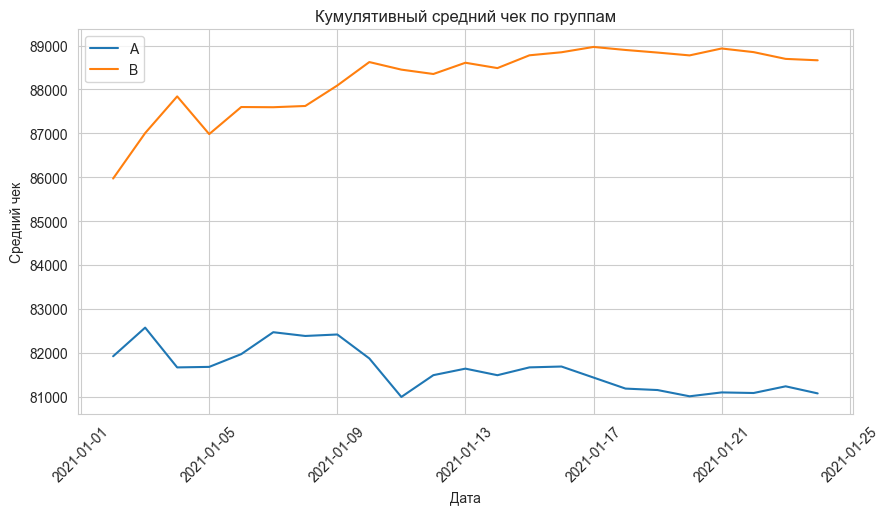

In [19]:
for group in daily['group'].unique():
    temp = daily[daily['group'] == group]
    plt.plot(temp['date'], temp['cum_avg_check'], label=group)

plt.title('Кумулятивный средний чек по группам')
plt.xlabel('Дата')
plt.ylabel('Средний чек')
plt.legend()
plt.xticks(rotation=45)
plt.show()

Кумулятивные метрики к концу теста стабилизируются, резких колебаний становится меньше. Это говорит о том, что тест можно считать завершённым, а полученные результаты — достаточно надёжными для интерпретации.

Далее проведем статистический анализ

Конверсия — это доля, значит используем z-test для пропорций.

Гипотезы
H0: конверсии в группах A и B равны

H1: конверсии различаются

In [20]:
conv_data = df.groupby('group').agg(
    purchases=('purchase', 'sum'),
    visits=('purchase', 'count')
)

success = conv_data['purchases'].values
nobs = conv_data['visits'].values

z_stat, p_value = proportions_ztest(count=success, nobs=nobs)
z_stat, p_value

(np.float64(1.176469036591924), np.float64(0.23940749849829834))

In [30]:
alpha = 0.05

if p_value < alpha:
    print('Есть статистически значимая разница в конверсии.')
else:
    print('Статистически значимой разницы в конверсии нет.')

Статистически значимой разницы в конверсии нет.


In [22]:
daily_check_a = daily[daily['group'] == 'A']['avg_check'].dropna()
daily_check_b = daily[daily['group'] == 'B']['avg_check'].dropna()

In [23]:
print(shapiro(daily_check_a))
print(shapiro(daily_check_b))

ShapiroResult(statistic=np.float64(0.9469830882712041), pvalue=np.float64(0.25307406517246855))
ShapiroResult(statistic=np.float64(0.9269076148181716), pvalue=np.float64(0.09378219197381865))


Для проверки нормальности распределения ежедневного среднего чека в группах A и B был использован тест Шапиро–Уилка.

Полученные p-value для обеих групп превышают уровень значимости 0.05, поэтому нулевая гипотеза о нормальности распределения не отвергается.

Следовательно, распределение ежедневного среднего чека в обеих группах можно считать близким к нормальному.

Гипотезы

 - H0: распределения ежедневного среднего чека одинаковы

 - H1: распределения различаются

In [24]:
stat, p_value_check = mannwhitneyu(daily_check_a, daily_check_b, alternative='two-sided')
stat, p_value_check

(np.float64(3.0), np.float64(9.811472278835978e-09))

In [25]:
if p_value_check < alpha:
    print('Есть статистически значимая разница в ежедневном среднем чеке.')
else:
    print('Статистически значимой разницы в ежедневном среднем чеке нет.')

Есть статистически значимая разница в ежедневном среднем чеке.


In [26]:
for group in ['A', 'B']:
    purchases = conv_data.loc[group, 'purchases']
    visits = conv_data.loc[group, 'visits']
    low, high = proportion_confint(count=purchases, nobs=visits, alpha=0.05, method='normal')
    print(group, low, high)

A 0.11867227948934625 0.12201812083548325
B 0.11726492136317732 0.12059284547017779


Доверительные интервалы перекрываются

Поэтому нельзя уверенно сказать, что конверсия одной группы выше другой

In [27]:
p_a = conv_data.loc['A', 'purchases'] / conv_data.loc['A', 'visits']
p_b = conv_data.loc['B', 'purchases'] / conv_data.loc['B', 'visits']

n_a = conv_data.loc['A', 'visits']
n_b = conv_data.loc['B', 'visits']

diff = p_b - p_a
se = np.sqrt(p_a*(1-p_a)/n_a + p_b*(1-p_b)/n_b)
z = norm.ppf(0.975)

ci_low = diff - z * se
ci_high = diff + z * se

diff, ci_low, ci_high

(np.float64(-0.001416316745737195),
 np.float64(-0.0037758576531742106),
 np.float64(0.0009432241616998205))

In [28]:
def mean_ci(x, confidence=0.95):
    x = np.array(x)
    mean = x.mean()
    std = x.std(ddof=1)
    se = std / np.sqrt(len(x))
    z = norm.ppf((1 + confidence) / 2)
    return mean, mean - z * se, mean + z * se

print('A:', mean_ci(daily_check_a))
print('B:', mean_ci(daily_check_b))

A: (np.float64(80969.2850990052), np.float64(79703.89335301725), np.float64(82234.67684499314))
B: (np.float64(88575.71551361024), np.float64(87677.99926201915), np.float64(89473.43176520133))


A
mean ≈ 80696
CI ≈ [79703 ; 82234]

B
mean ≈ 88575
CI ≈ [87677 ; 89473]

Интервалы не перекрываются.

A: ~79k — 82k

B: ~87k — 89k

Это означает:

средний чек в группе B значительно выше.

### Итоги

В результате анализа A/B теста были рассмотрены две ключевые бизнес-метрики: конверсия покупки и ежедневный средний чек.

Анализ доверительных интервалов конверсии показал, что интервалы групп A и B перекрываются, а доверительный интервал разницы конверсий включает значение 0. Это означает отсутствие статистически значимого различия конверсии между вариантами посадочной страницы.

При анализе ежедневного среднего чека было выявлено, что доверительные интервалы групп не перекрываются, а средний чек в группе B значительно выше, чем в группе A.

Таким образом, вариант B позволяет получать более высокий доход с каждой покупки, не снижая конверсию.

Рекомендуется использовать вариант посадочной страницы B, так как он обеспечивает более высокий средний чек при сопоставимом уровне конверсии.